# MODIS Vegetation Analysis - Production Notebook

**Enhanced version with:**
- Organized output structure
- Administrative level analysis
- Comprehensive reporting
- Error handling and logging

---

## 1. Setup and Configuration

In [12]:
# Import the production analyzer
from modis_vegetation_analyzer import MODISVegetationAnalyzer
from report_utils import ReportGenerator, generate_markdown_report
from helper_utils import save_uploaded_file, create_upload_widget
import json
from pathlib import Path

print("✅ Imports successful")

✅ Imports successful


In [13]:
# Define configuration (customize as needed)
config = {
    "ee_project": "ee-my-ndungu",
    "output_base_dir": "modis_outputs",
    "year": 2024,
    "indices": ["NDVI", "EVI", "VCI"],
    "composite_methods": ["mean"],
    "scale": 250
}

# Save config
with open('notebook_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Configuration saved")
print(json.dumps(config, indent=2))

✅ Configuration saved
{
  "ee_project": "ee-my-ndungu",
  "output_base_dir": "modis_outputs",
  "year": 2024,
  "indices": [
    "NDVI",
    "EVI",
    "VCI"
  ],
  "composite_methods": [
    "mean"
  ],
  "scale": 250
}


## 2. Initialize Analyzer

In [14]:
# Initialize the analyzer with config
analyzer = MODISVegetationAnalyzer(config_path='notebook_config.json')

# Initialize Earth Engine
analyzer.initialize_ee()

print("✅ Analyzer initialized")

2026-02-16 15:40:37,597 - MODISAnalyzer - INFO - ✅ Earth Engine initialized with project: ee-my-ndungu
2026-02-16 15:40:37,597 - MODISAnalyzer - INFO - ✅ Earth Engine initialized with project: ee-my-ndungu


✅ Analyzer initialized


## 3. Load Area of Interest (AOI)

In [15]:
# Upload AOI file using widget
from IPython.display import display

upload_widget = create_upload_widget()
display(upload_widget)
print("⏳ Please upload your AOI file...")

FileUpload(value=(), accept='.zip,.geojson,.json,.shp,.dbf,.shx,.prj', description='📁 Upload AOI')

⏳ Please upload your AOI file...


In [16]:
# Process uploaded file
if upload_widget.value:
    try:
        # Save uploaded file using helper function
        filename = save_uploaded_file(upload_widget)
        print(f"✅ File saved: {filename}")
        
        # Load AOI
        analyzer.load_aoi(filename)
        
        print(f"✅ AOI loaded successfully!")
        print(f"   Features: {len(analyzer.aoi_gdf)}")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        print("   Please check your file and try again.")
else:
    print("⚠️  No file uploaded. Please upload a file in the cell above.")

2026-02-16 15:40:55,526 - MODISAnalyzer - INFO - 📂 Loading AOI from: Kiambu.geojson
2026-02-16 15:40:55,526 - MODISAnalyzer - INFO - 📂 Loading AOI from: Kiambu.geojson
2026-02-16 15:40:55,656 - MODISAnalyzer - INFO - ✅ AOI loaded successfully with 1 features
2026-02-16 15:40:55,656 - MODISAnalyzer - INFO - ✅ AOI loaded successfully with 1 features


✅ File saved: Kiambu.geojson
✅ AOI loaded successfully!
   Features: 1


## 4. Visualize AOI (Optional)

In [17]:
import geemap

# Create interactive map
Map = geemap.Map()
Map.centerObject(analyzer.aoi, zoom=8)
Map.addLayer(analyzer.aoi, {}, 'AOI Boundary')
Map

Map(center=[-1.0663333046950283, 36.82274849394715], controls=(WidgetControl(options=['position', 'transparent…

## 5. Run Complete Analysis

This will:
1. Create organized output structure
2. Fetch MODIS data
3. Calculate vegetation indices
4. Generate monthly composites
5. Calculate statistics
6. Analyze by administrative levels
7. Create visualizations

In [20]:
# Create output structure
analyzer.create_output_structure()
print(f"📁 Output directory: {analyzer.output_dir}")

2026-02-16 15:41:25,215 - MODISAnalyzer - INFO - 📁 Output structure created at: modis_outputs/analysis_20260216_154125
2026-02-16 15:41:25,215 - MODISAnalyzer - INFO - 📁 Output structure created at: modis_outputs/analysis_20260216_154125


📁 Output directory: modis_outputs/analysis_20260216_154125


In [18]:
# Fetch MODIS data
year = config['year']
start_date = f"{year}-01-01"
end_date = f"{year}-12-31"

print(f"📡 Fetching MODIS data for {year}...")
collection = analyzer.get_modis_data(start_date, end_date)

# Calculate VCI
print("🧮 Calculating VCI...")
historical_start = f"{year-10}-01-01"
historical_end = f"{year-1}-12-31"
collection = analyzer.calculate_vci(collection, historical_start, historical_end)

print("✅ Data prepared")

📡 Fetching MODIS data for 2024...


2026-02-16 15:41:11,448 - MODISAnalyzer - INFO - 📡 Retrieved 23 MODIS images from 2024-01-01 to 2024-12-31
2026-02-16 15:41:11,448 - MODISAnalyzer - INFO - 📡 Retrieved 23 MODIS images from 2024-01-01 to 2024-12-31


🧮 Calculating VCI...
✅ Data prepared


In [21]:
# Create monthly composites
print("🎨 Creating monthly composites...")
composites = analyzer.create_monthly_composites(collection, year)

print("🖼️  Exporting composite images...")
analyzer.export_composite_images(composites)

print("✅ Composites complete")

2026-02-16 15:41:28,886 - MODISAnalyzer - INFO - ✅ Created 36 monthly composites
2026-02-16 15:41:28,886 - MODISAnalyzer - INFO - ✅ Created 36 monthly composites
2026-02-16 15:41:28,893 - MODISAnalyzer - INFO - 🖼️  Exporting composite visualizations...
2026-02-16 15:41:28,893 - MODISAnalyzer - INFO - 🖼️  Exporting composite visualizations...


🎨 Creating monthly composites...
🖼️  Exporting composite images...


2026-02-16 15:44:57,623 - MODISAnalyzer - WARNING - Failed to download EVI_mean_2024_11.png: HTTP Error 500: Internal Server Error
2026-02-16 15:44:57,623 - MODISAnalyzer - WARNING - Failed to download EVI_mean_2024_11.png: HTTP Error 500: Internal Server Error
2026-02-16 15:45:41,394 - MODISAnalyzer - WARNING - Failed to download NDVI_mean_2024_12.png: HTTP Error 500: Internal Server Error
2026-02-16 15:45:41,394 - MODISAnalyzer - WARNING - Failed to download NDVI_mean_2024_12.png: HTTP Error 500: Internal Server Error
2026-02-16 15:45:42,999 - MODISAnalyzer - WARNING - Failed to download EVI_mean_2024_12.png: HTTP Error 500: Internal Server Error
2026-02-16 15:45:42,999 - MODISAnalyzer - WARNING - Failed to download EVI_mean_2024_12.png: HTTP Error 500: Internal Server Error
2026-02-16 15:45:45,658 - MODISAnalyzer - INFO - ✅ Composite export complete
2026-02-16 15:45:45,658 - MODISAnalyzer - INFO - ✅ Composite export complete


✅ Composites complete


In [22]:
# Calculate statistics
print("📊 Calculating monthly statistics...")
stats_df = analyzer.calculate_statistics(collection, year)

print("\n📈 Monthly Statistics Summary:")
display(stats_df[['Month', 'NDVI_mean', 'EVI_mean', 'VCI_mean']])

print("✅ Statistics calculated")

2026-02-16 15:45:50,954 - MODISAnalyzer - INFO - 📊 Calculating monthly statistics...
2026-02-16 15:45:50,954 - MODISAnalyzer - INFO - 📊 Calculating monthly statistics...


📊 Calculating monthly statistics...


2026-02-16 15:46:34,394 - MODISAnalyzer - INFO - ✅ Statistics saved to modis_outputs/analysis_20260216_154125/statistics/monthly_summary_2024.csv
2026-02-16 15:46:34,394 - MODISAnalyzer - INFO - ✅ Statistics saved to modis_outputs/analysis_20260216_154125/statistics/monthly_summary_2024.csv



📈 Monthly Statistics Summary:


,Month,NDVI_mean,EVI_mean,VCI_mean
0,1,6565.640215,4200.618746,72.463198
1,2,6699.436915,3854.273893,73.677015
2,3,6608.058039,3585.546294,72.498379
3,4,7135.144433,4151.662575,79.291335
4,5,7154.120384,4422.988294,79.696339
5,6,6952.869870,4338.355536,77.209470
6,7,6750.276415,4043.721221,74.675430
7,8,5030.743194,2842.504151,53.887674
8,9,6044.372049,3443.817952,65.355549
9,10,6429.478484,3398.601809,70.081926


✅ Statistics calculated


In [23]:
# Create trend plots
print("📈 Creating trend plots...")
analyzer.create_trend_plots(stats_df, year)

print("✅ Trends plotted")

2026-02-16 15:51:41,697 - MODISAnalyzer - INFO - 📈 Creating trend plots...
2026-02-16 15:51:41,697 - MODISAnalyzer - INFO - 📈 Creating trend plots...


📈 Creating trend plots...


2026-02-16 15:51:48,208 - MODISAnalyzer - INFO - ✅ Trend plots created
2026-02-16 15:51:48,208 - MODISAnalyzer - INFO - ✅ Trend plots created


✅ Trends plotted


In [24]:
# Generate metadata
analyzer.generate_metadata()

print("✅ Analysis complete!")
print(f"\n📁 All results saved to: {analyzer.output_dir}")

2026-02-16 15:51:51,356 - MODISAnalyzer - INFO - 📄 Metadata saved to modis_outputs/analysis_20260216_154125/metadata/analysis_metadata.json
2026-02-16 15:51:51,356 - MODISAnalyzer - INFO - 📄 Metadata saved to modis_outputs/analysis_20260216_154125/metadata/analysis_metadata.json


✅ Analysis complete!

📁 All results saved to: modis_outputs/analysis_20260216_154125


## 6. View Results


NDVI Trend:


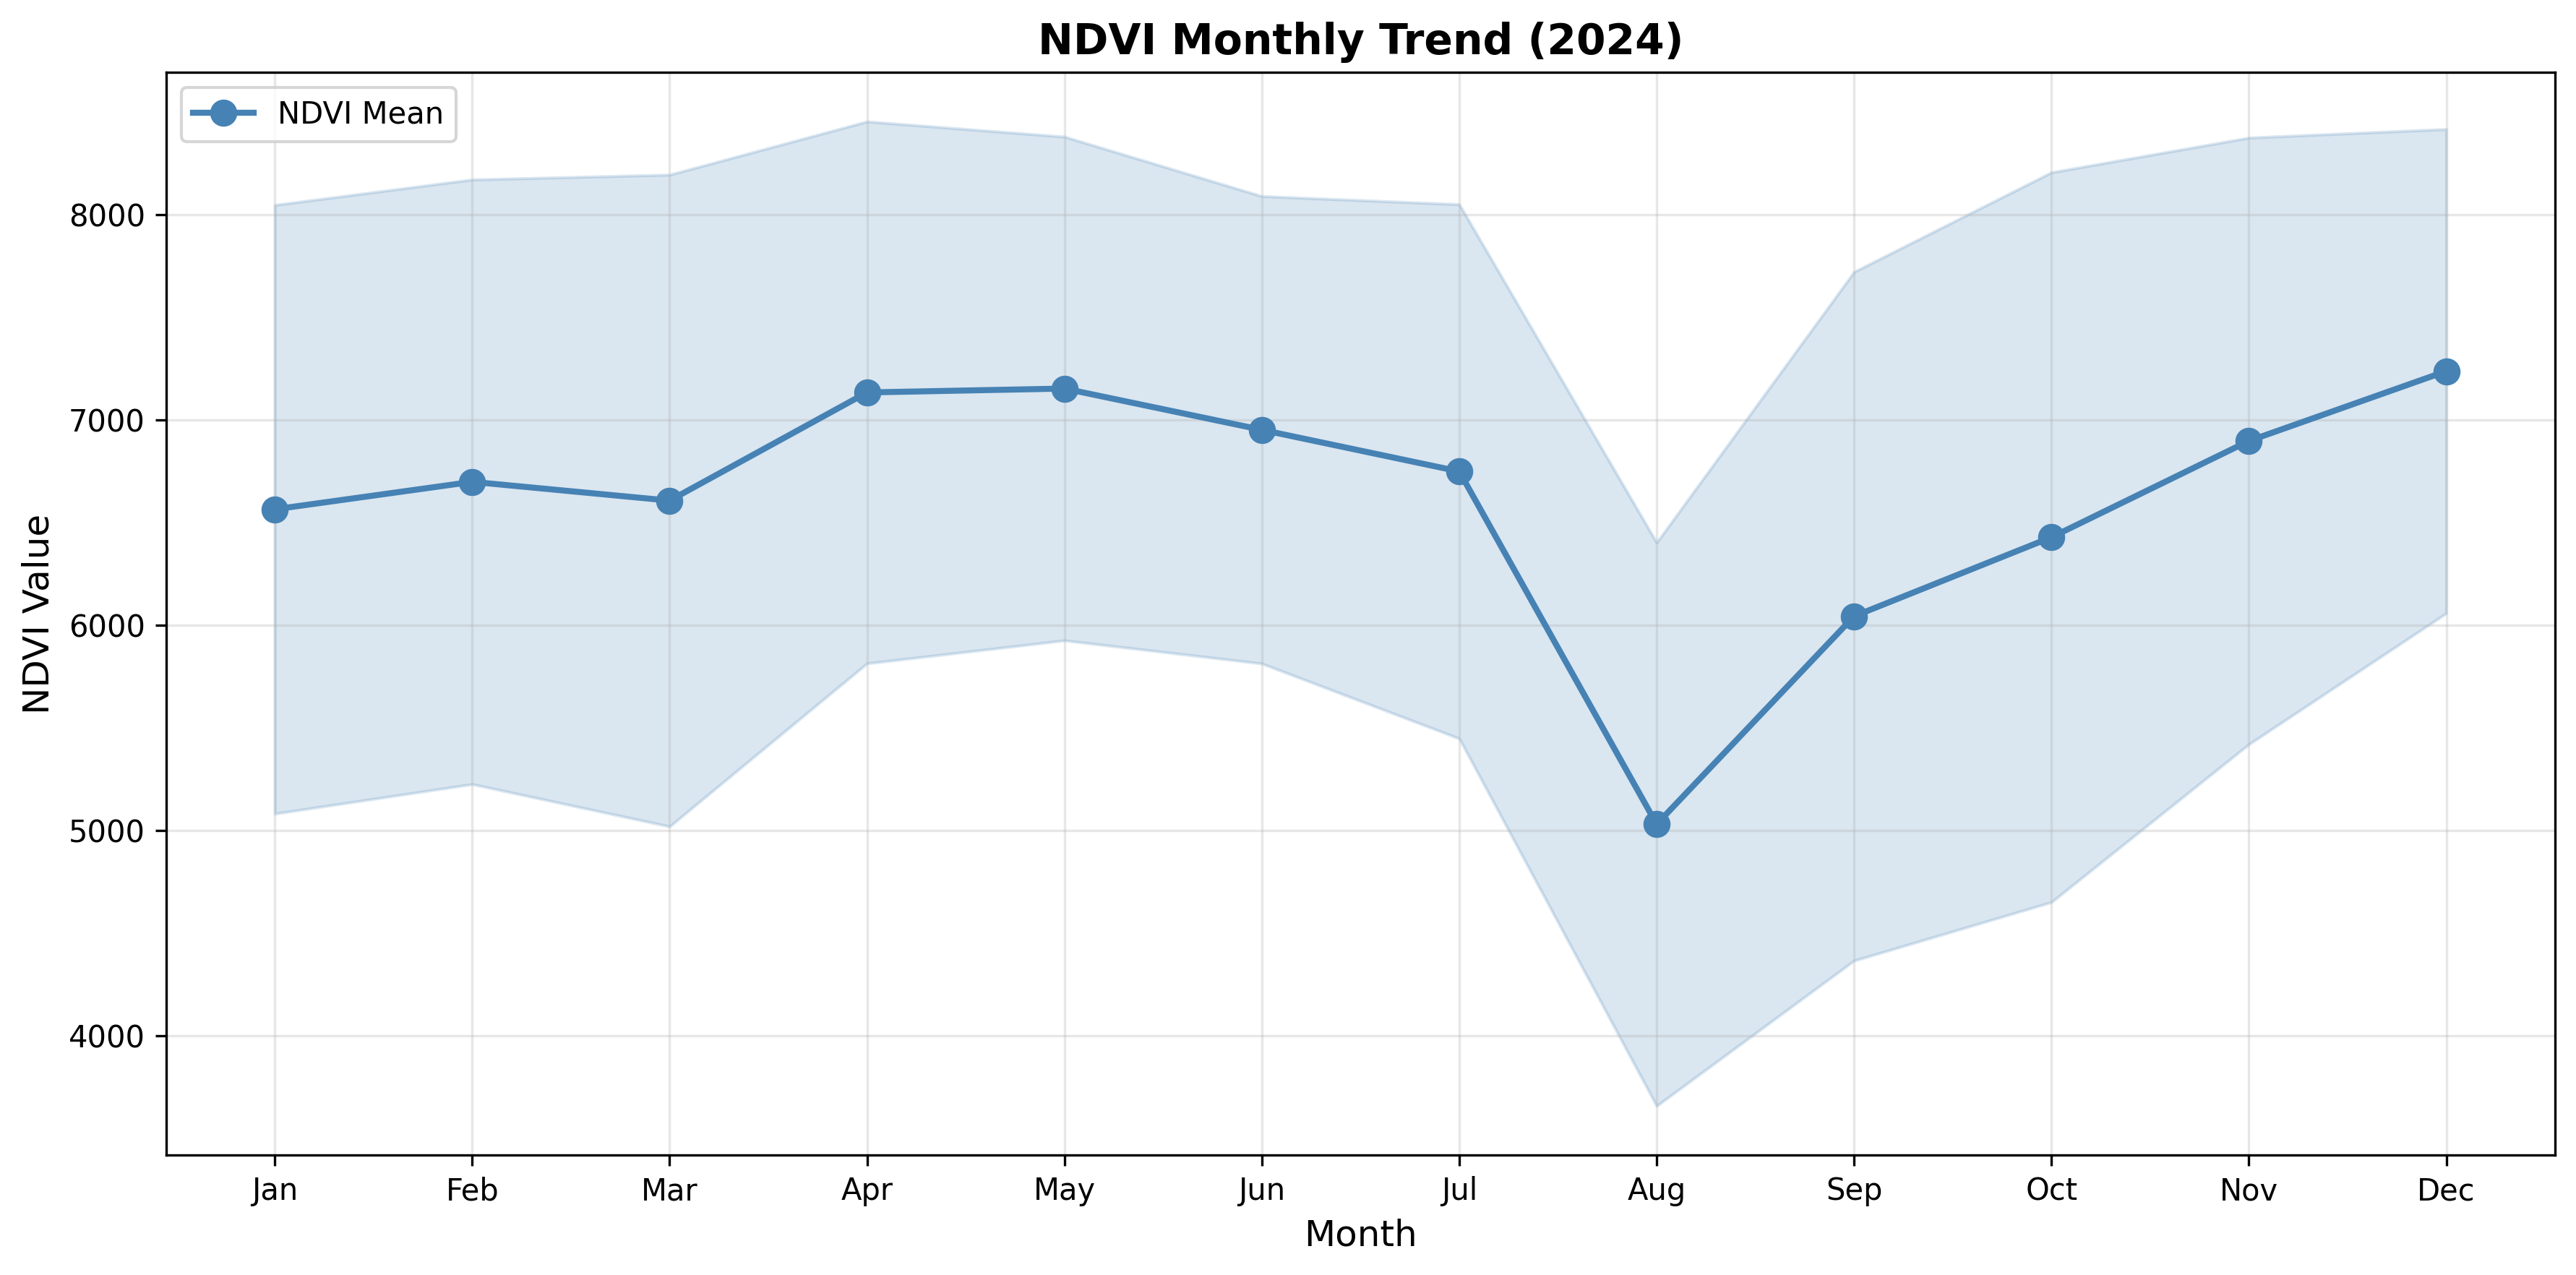


EVI Trend:


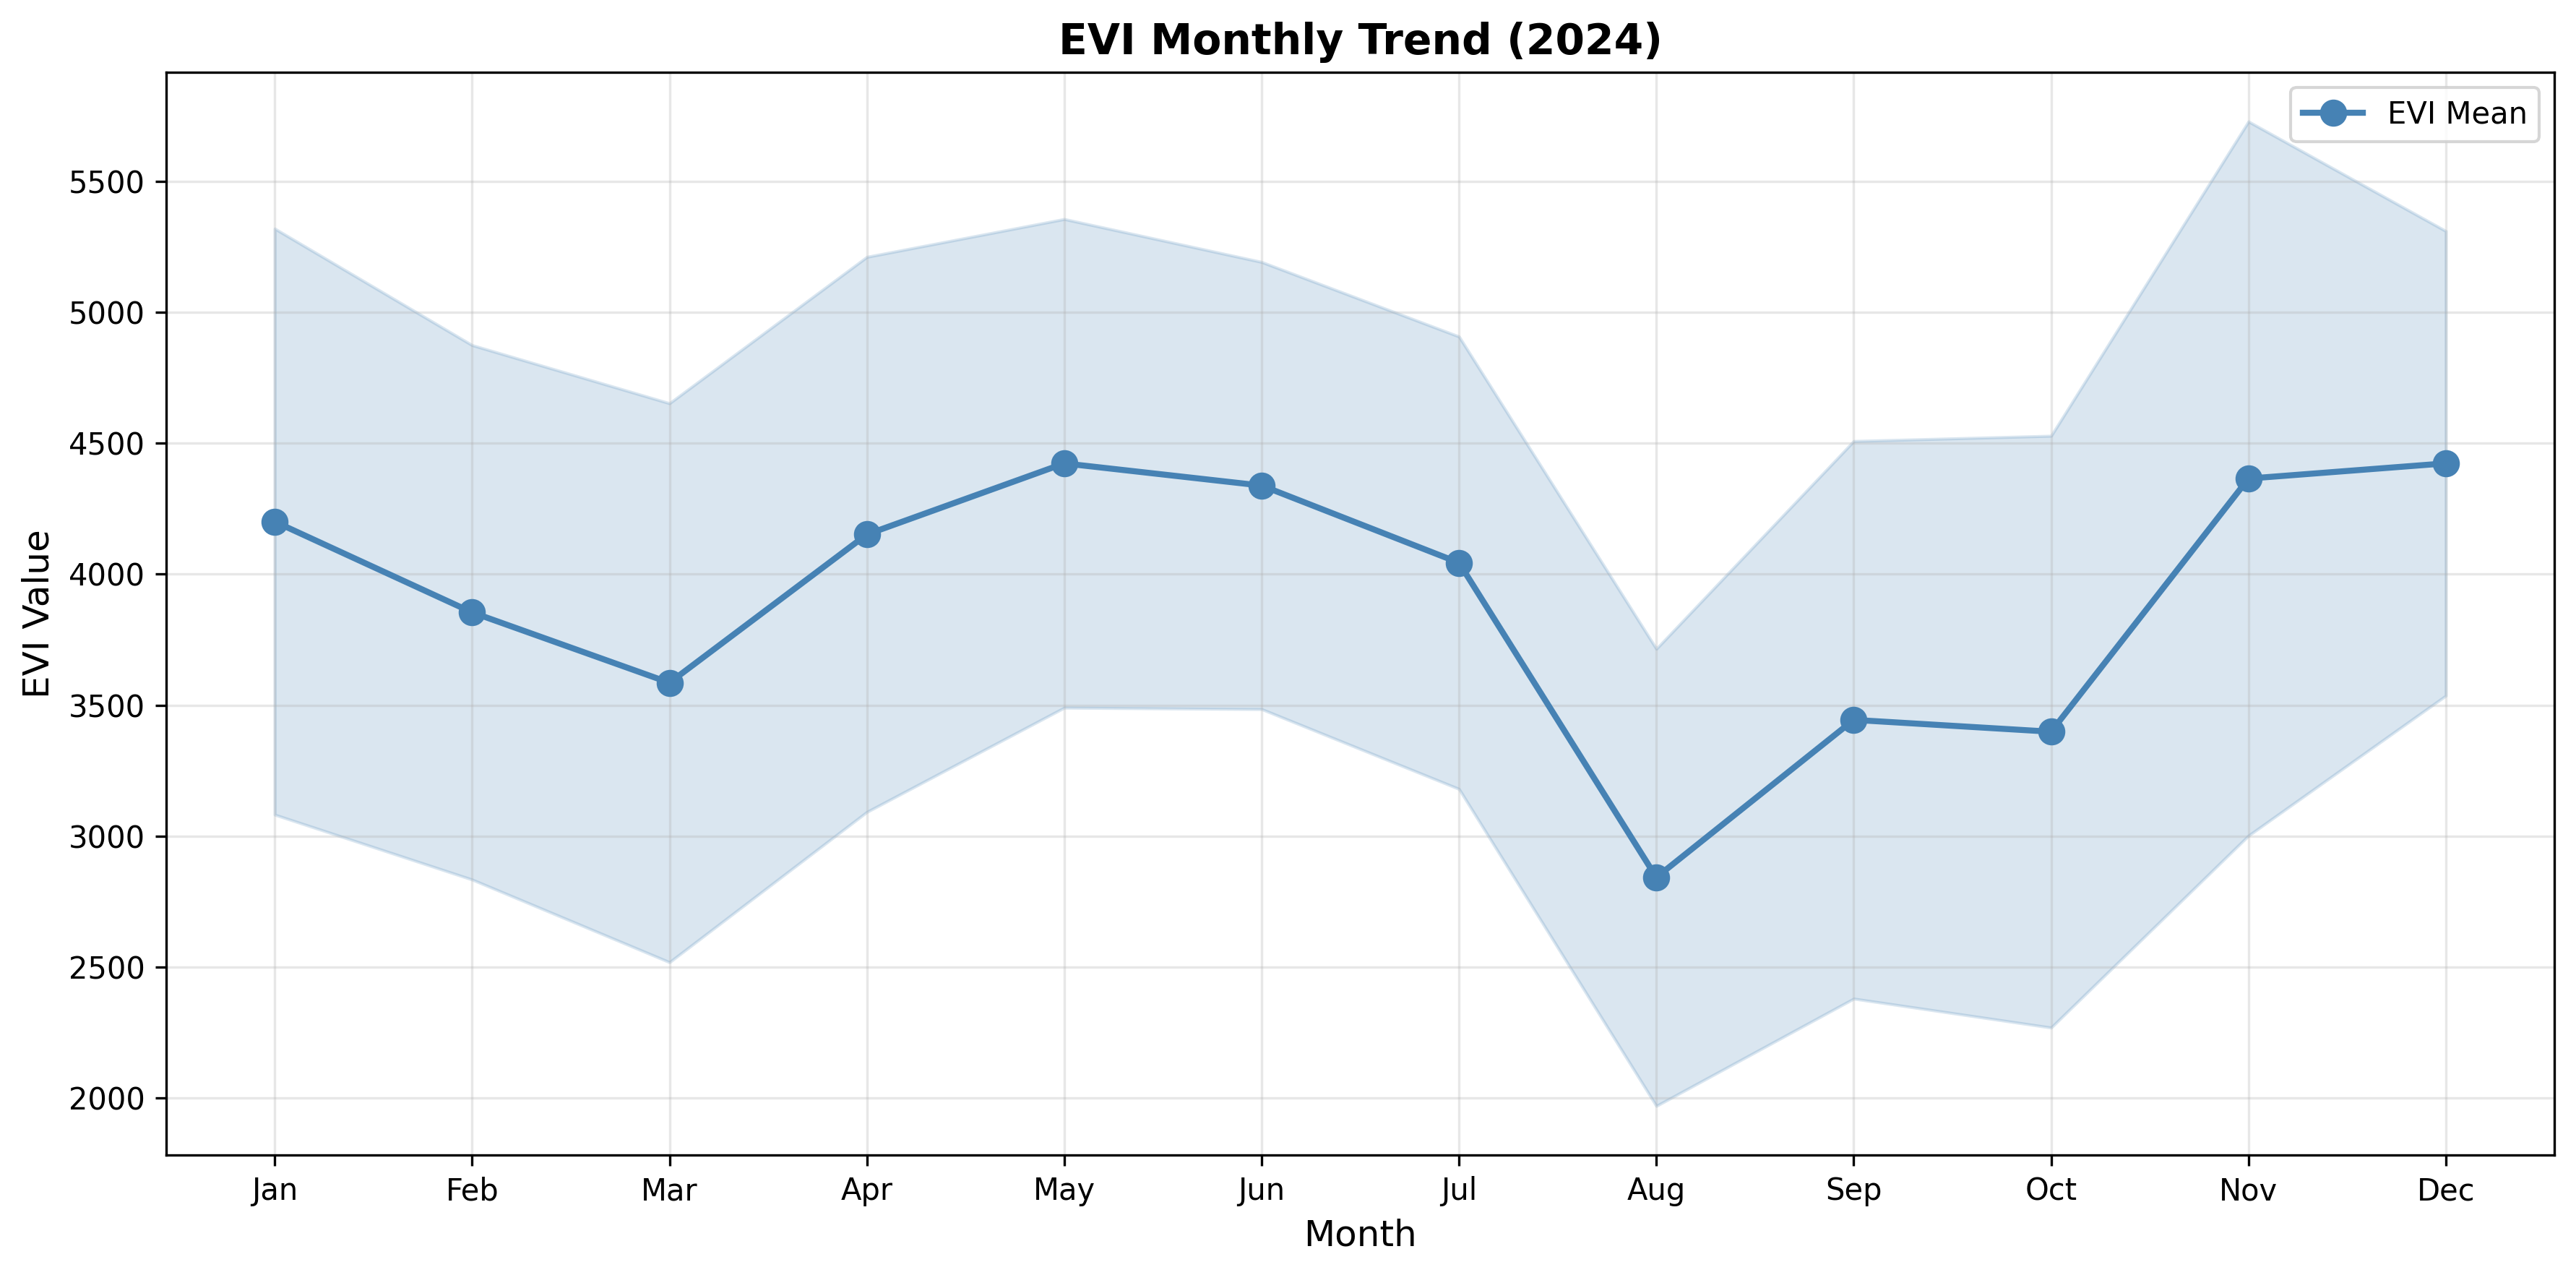


VCI Trend:


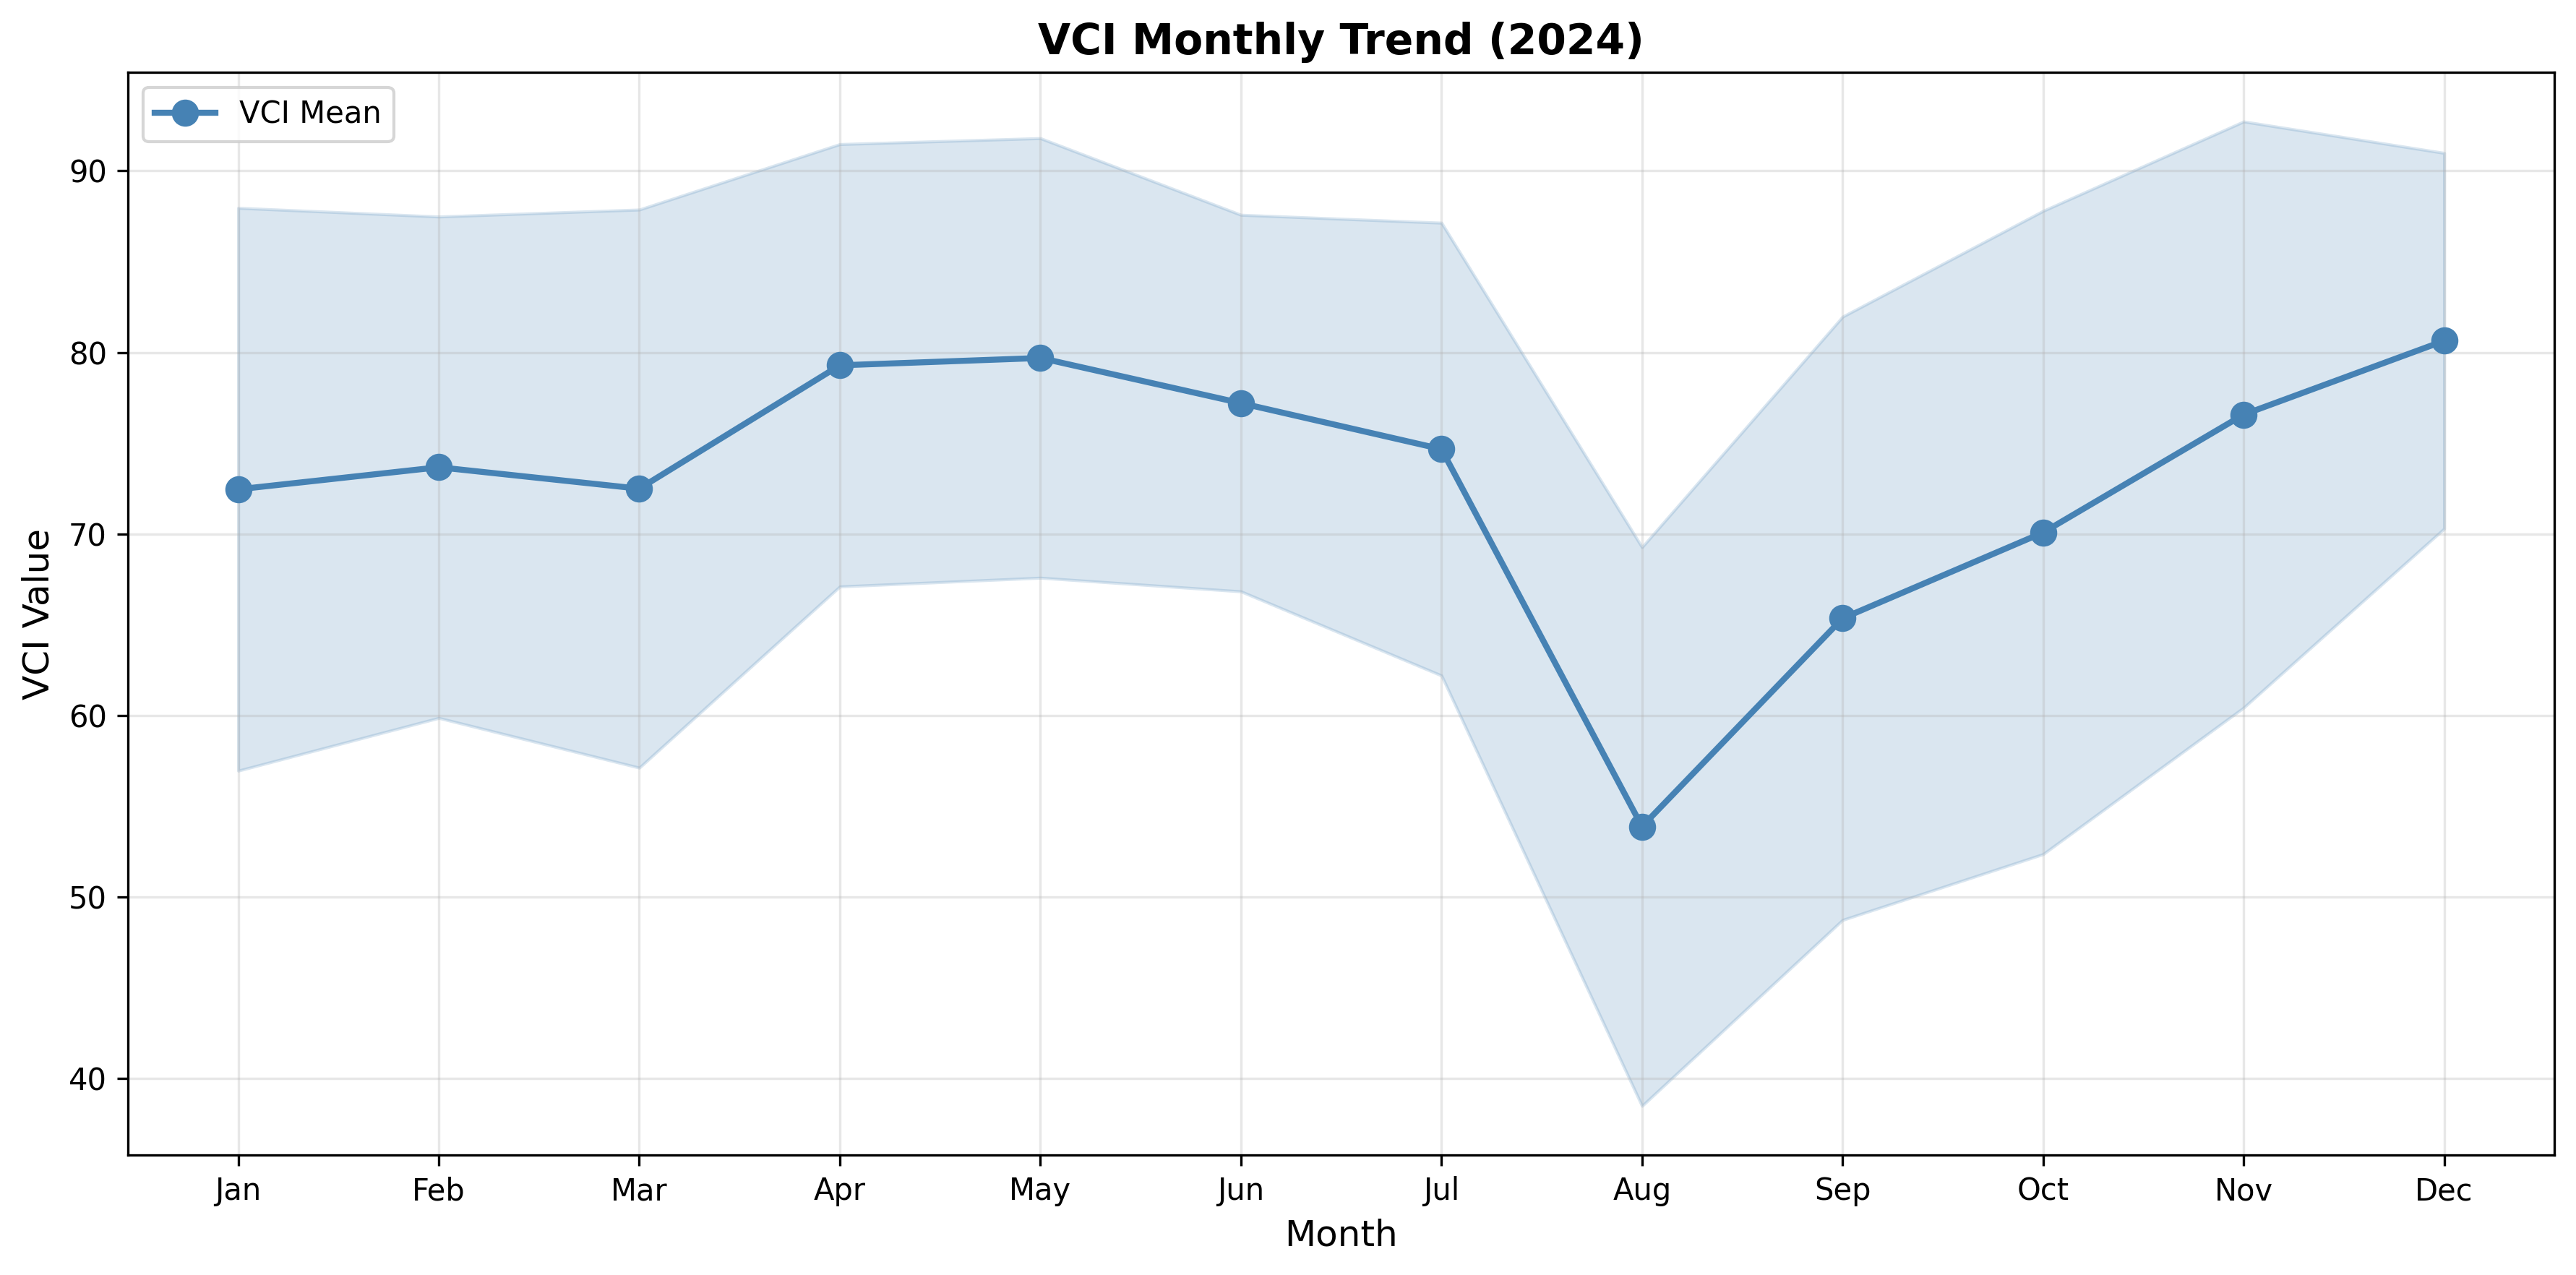

In [25]:
# Display trend plots
from IPython.display import Image, display
import os

trends_dir = analyzer.output_dir / "trends"

for index in config['indices']:
    img_path = trends_dir / f"{index}_trend_{year}.png"
    if img_path.exists():
        print(f"\n{index} Trend:")
        display(Image(filename=str(img_path)))

## 7. Generate Reports

In [26]:
# Generate markdown report
print("📝 Generating markdown report...")
md_path = generate_markdown_report(analyzer.output_dir, year)
print(f"✅ Markdown report: {md_path}")

# Generate PDF report (if reportlab is installed)
try:
    print("\n📘 Generating PDF report...")
    report_gen = ReportGenerator(analyzer.output_dir)
    pdf_path = report_gen.create_comprehensive_report(year)
    print(f"✅ PDF report: {pdf_path}")
except Exception as e:
    print(f"⚠️  PDF generation failed: {e}")
    print("   Install reportlab: pip install reportlab")

📝 Generating markdown report...
📝 Markdown report generated: modis_outputs/analysis_20260216_154125/MODIS_Report_2024.md
✅ Markdown report: modis_outputs/analysis_20260216_154125/MODIS_Report_2024.md

📘 Generating PDF report...
📘 Comprehensive PDF report generated: modis_outputs/analysis_20260216_154125/MODIS_Comprehensive_Report_2024.pdf
✅ PDF report: modis_outputs/analysis_20260216_154125/MODIS_Comprehensive_Report_2024.pdf


## 8. Analysis Summary

In [27]:
print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\n📅 Year: {year}")
print(f"📁 Output: {analyzer.output_dir}")
print(f"\n📊 Indices Analyzed: {', '.join(config['indices'])}")
print(f"\n📈 Outputs Generated:")
print(f"   ✅ Monthly composites")
print(f"   ✅ Trend plots")
print(f"   ✅ Statistical summaries")
print(f"   ✅ Reports")
print(f"\n🎉 Analysis successful!")
print("="*60)

ANALYSIS COMPLETE

📅 Year: 2024
📁 Output: modis_outputs/analysis_20260216_154125

📊 Indices Analyzed: NDVI, EVI, VCI

📈 Outputs Generated:
   ✅ Monthly composites
   ✅ Trend plots
   ✅ Statistical summaries
   ✅ Reports

🎉 Analysis successful!
